###Imports e Upload do dataset

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import r2_score, mean_squared_error
from scipy.optimize import basinhopping
import xgboost as xgb
from sklearn.model_selection import cross_val_predict, KFold
import matplotlib.colors as colors
from scipy.stats import pearsonr
import warnings
warnings.filterwarnings('ignore')

In [ ]:
# df_acertos = pd.read_parquet(r'C:\Users\Usuário\Desktop\PCD\tabelas_parquet\acertos_subamostra.parquet')
# df_enems = pd.read_parquet(r'C:\Users\Usuário\Desktop\PCD\tabelas_parquet\enems_subamostra.parquet')
# df_gabaritos = pd.read_parquet(r'C:\Users\Usuário\Desktop\PCD\tabelas_parquet\gabaritos.parquet')

df_acertos = pd.read_parquet('acertos_subamostra.parquet')
df_enems = pd.read_parquet('enems_subamostra.parquet')
df_gabaritos = pd.read_parquet('gabaritos.parquet')



df_enems = df_enems.merge(df_gabaritos[['CO_PROVA', 'COR']], left_on='CO_PROVA_MT', right_on='CO_PROVA')
df = df_acertos.merge(df_enems[['NU_INSCRICAO', 'COR']], left_on='NU_INSCRICAO', right_on='NU_INSCRICAO')

df = df[(df['NU_ANO'] == 2023) & ~df['COR'].isna()]
df


,NU_INSCRICAO,NU_ANO,TP_PRESENCA_CN,TP_PRESENCA_CH,TP_PRESENCA_LC,TP_PRESENCA_MT,TP_LINGUA,NU_NOTA_LC,NU_NOTA_CH,NU_NOTA_CN,...,Q177,Q178,Q179,Q180,Q181,Q182,Q183,Q184,Q185,COR
151170,210058036237,2023,1,1,1,1,0,447.5,511.4,499.8,...,1,0,1,0,0,0,0,1,1,Azul
151171,210058036273,2023,1,1,1,1,0,591.8,648.6,647.7,...,0,0,0,0,1,1,1,1,1,Azul
151172,210058036463,2023,1,1,1,1,0,588.4,658.2,640.3,...,0,1,1,0,1,1,1,1,1,Amarelo
151173,210058036521,2023,1,1,1,1,1,685.4,671.1,657.6,...,0,1,1,0,0,1,0,0,0,Azul
151174,210058036625,2023,1,1,1,1,1,501.9,457.4,398.0,...,0,0,1,0,0,1,1,1,0,Azul
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
192066,210062061309,2023,1,1,1,1,0,481.8,429.5,493.4,...,0,0,1,0,1,1,1,1,1,Rosa
192067,210062061468,2023,1,1,1,1,0,545.3,518.8,470.1,...,0,0,1,0,0,0,0,0,1,Rosa
192068,210062061543,2023,1,1,1,1,0,547.0,464.0,530.2,...,1,0,0,0,1,0,1,0,1,Azul
192069,210062061582,2023,1,1,1,1,0,541.9,545.1,560.9,...,0,1,0,0,0,0,0,1,0,Branco


In [ ]:
df.columns

Index(['NU_INSCRICAO', 'NU_ANO', 'TP_PRESENCA_CN', 'TP_PRESENCA_CH',
       'TP_PRESENCA_LC', 'TP_PRESENCA_MT', 'TP_LINGUA', 'NU_NOTA_LC',
       'NU_NOTA_CH', 'NU_NOTA_CN',
       ...
       'Q177', 'Q178', 'Q179', 'Q180', 'Q181', 'Q182', 'Q183', 'Q184', 'Q185',
       'COR'],
      dtype='object', length=200)

###Primeiro treinamento

* De início, foco apenas na prova de MATEMÁTICA

In [ ]:
df = df[df['NU_NOTA_MT']>1]
df

,NU_INSCRICAO,NU_ANO,TP_PRESENCA_CN,TP_PRESENCA_CH,TP_PRESENCA_LC,TP_PRESENCA_MT,TP_LINGUA,NU_NOTA_LC,NU_NOTA_CH,NU_NOTA_CN,...,Q177,Q178,Q179,Q180,Q181,Q182,Q183,Q184,Q185,COR
151170,210058036237,2023,1,1,1,1,0,447.5,511.4,499.8,...,1,0,1,0,0,0,0,1,1,Azul
151171,210058036273,2023,1,1,1,1,0,591.8,648.6,647.7,...,0,0,0,0,1,1,1,1,1,Azul
151172,210058036463,2023,1,1,1,1,0,588.4,658.2,640.3,...,0,1,1,0,1,1,1,1,1,Amarelo
151173,210058036521,2023,1,1,1,1,1,685.4,671.1,657.6,...,0,1,1,0,0,1,0,0,0,Azul
151174,210058036625,2023,1,1,1,1,1,501.9,457.4,398.0,...,0,0,1,0,0,1,1,1,0,Azul
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
192066,210062061309,2023,1,1,1,1,0,481.8,429.5,493.4,...,0,0,1,0,1,1,1,1,1,Rosa
192067,210062061468,2023,1,1,1,1,0,545.3,518.8,470.1,...,0,0,1,0,0,0,0,0,1,Rosa
192068,210062061543,2023,1,1,1,1,0,547.0,464.0,530.2,...,1,0,0,0,1,0,1,0,1,Azul
192069,210062061582,2023,1,1,1,1,0,541.9,545.1,560.9,...,0,1,0,0,0,0,0,1,0,Branco


In [ ]:
colunas_desejadas = ['NU_NOTA_MT'] + [f'Q{i}' for i in range(141, 186) if i != 169]  # ANULADA
df = df[colunas_desejadas].dropna()

df = df.astype(float)

treino_val_test = [80, 10, 10]
normalized_split = [x / sum(treino_val_test) for x in treino_val_test]

train_size = int(len(df) * normalized_split[0])
val_size = int(len(df) * normalized_split[1])
test_size = len(df) - train_size - val_size

# Dividindo o DataFrame
df_train = df[:train_size]
df_val = df[train_size:train_size+val_size]
df_test = df[train_size+val_size:]

# Calculando média e std no treino
mean_train = df_train['NU_NOTA_MT'].mean()
std_train = df_train['NU_NOTA_MT'].std()

# Normalizando usando valores do treino
df_train['NU_NOTA_MT'] = (df_train['NU_NOTA_MT'] - mean_train) / std_train
df_val['NU_NOTA_MT'] = (df_val['NU_NOTA_MT'] - mean_train) / std_train
df_test['NU_NOTA_MT'] = (df_test['NU_NOTA_MT'] - mean_train) / std_train

df_train

<ipython-input-5-d6479066e70d>:23: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_train['NU_NOTA_MT'] = (df_train['NU_NOTA_MT'] - mean_train) / std_train
<ipython-input-5-d6479066e70d>:24: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_val['NU_NOTA_MT'] = (df_val['NU_NOTA_MT'] - mean_train) / std_train
<ipython-input-5-d6479066e70d>:25: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in t

,NU_NOTA_MT,Q141,Q142,Q143,Q144,Q145,Q146,Q147,Q148,Q149,...,Q176,Q177,Q178,Q179,Q180,Q181,Q182,Q183,Q184,Q185
151170,-0.396550,1.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,1.0
151171,1.211509,0.0,1.0,0.0,0.0,0.0,1.0,0.0,1.0,1.0,...,1.0,0.0,0.0,0.0,0.0,1.0,1.0,1.0,1.0,1.0
151172,1.612331,1.0,1.0,0.0,1.0,0.0,0.0,1.0,1.0,1.0,...,1.0,0.0,1.0,1.0,0.0,1.0,1.0,1.0,1.0,1.0
151173,0.396346,1.0,1.0,0.0,1.0,0.0,0.0,0.0,1.0,1.0,...,0.0,0.0,1.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0
151174,-0.688418,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,1.0,0.0,0.0,1.0,1.0,1.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
183865,-0.409275,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,...,0.0,1.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,1.0
183866,-1.012893,0.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,...,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0
183867,0.391574,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,...,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,1.0,0.0
183868,-1.223643,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,1.0,1.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0


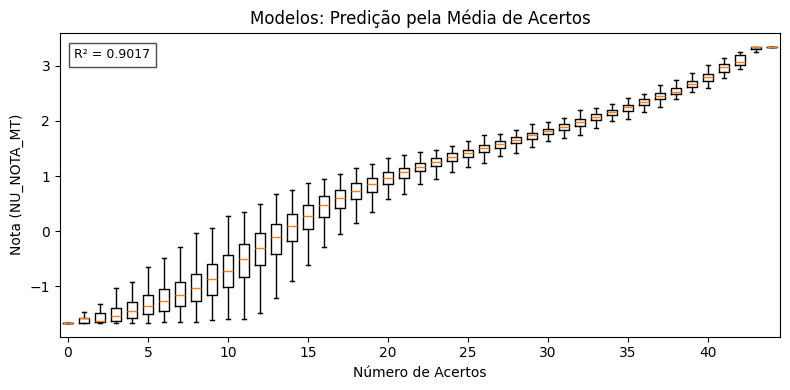

In [ ]:
acertos = df_train.drop('NU_NOTA_MT', axis=1).sum(axis=1).astype(int)
notas = df_train['NU_NOTA_MT']

df_grouped = df_train.copy()
df_grouped['acertos'] = acertos
media = df_grouped.groupby('acertos')['NU_NOTA_MT'].agg(['mean', 'std', 'count']).reset_index()

X_agrup = media['acertos'].values.reshape(-1, 1)
y_agrup = media['mean'].values

mapa_media = dict(zip(media['acertos'], media['mean']))
notas_estimadas_media = acertos.map(mapa_media)
r2_3 = r2_score(notas, notas_estimadas_media)

plt.figure(figsize=(8, 4))

# Boxplots para as notas por número de acertos com diminuição dos outliers
plt.boxplot([df_grouped[df_grouped['acertos'] == acerto]['NU_NOTA_MT'] for acerto in media['acertos']],
            positions=range(len(media['acertos'])), widths=0.6, showfliers=False)

# Ajuste dos rótulos do eixo X para a cada 5 unidades
plt.xticks(range(0, len(media['acertos']), 5), labels=[str(acerto) for acerto in media['acertos'][::5]])

plt.xlabel('Número de Acertos')
plt.ylabel('Nota (NU_NOTA_MT)')
plt.title('Modelos: Predição pela Média de Acertos')

# Adicionando o R² no gráfico
plt.text(0.02, 0.95, f'R² = {r2_3:.4f}', transform=plt.gca().transAxes, ha='left', va='top', fontsize=9, bbox=dict(facecolor='white', alpha=0.7))

plt.grid(False)

plt.tight_layout()
plt.show()


In [ ]:
def P(TRI, a, b, c): #função logística
    return c + (1 - c) / (1 + np.exp(-a*(TRI - b)))

In [ ]:
def custo_ridge(params, x, y, prioris, alpha=0.05):
    a, b, c = params
    y_pred = P(x, a, b, c)
    erro = np.sum((y - y_pred) ** 2)
    penalizacao = alpha * ((a-prioris[0])**2 + (b-prioris[1])**2 + (c-prioris[2])**2)
    return erro + penalizacao

In [ ]:
def otimizar_ridge(df_train, questoes, limites, custo_ridge, prioris, alpha=0.25):
    x = df_train['NU_NOTA_MT'].values
    parametros_ridge = pd.DataFrame(index=questoes, columns=['a', 'b', 'c'])

    for q in questoes:
        try:
            y = df_train[q].values

            # Definição da função com os argumentos fixos
            func = lambda params: custo_ridge(params, x, y, prioris, alpha)

            # Chute inicial razoável
            x0 = prioris

            # Constraint bounds para basinhopping
            minimizer_kwargs = {
                "method": "L-BFGS-B",
                "bounds": limites
            }

            # Executa o basinhopping
            resultado = basinhopping(func, x0, minimizer_kwargs=minimizer_kwargs, niter=25, disp=False)

            if resultado.lowest_optimization_result.success:
                parametros_ridge.loc[q] = resultado.x
            else:
                parametros_ridge.loc[q] = [np.nan, np.nan, np.nan]
                print(f"Erro ao ajustar a questão {q}: otimização não convergiu.")

        except Exception as e:
            print(f"Erro ao ajustar a questão {q}: {e}")
            parametros_ridge.loc[q] = [np.nan, np.nan, np.nan]

    return parametros_ridge


In [ ]:
questoes = [f'Q{i}' for i in range(141, 186) if i != 169]
limites = [(0.1, 5),(-4,4), (0,1)]
prioris = [2, 0, 0.2]
parametros = otimizar_ridge(df_train, questoes, limites, custo_ridge, prioris, alpha=0.25)
parametros

,a,b,c
Q141,2.590128,2.185296,0.269464
Q142,2.984974,0.64513,0.209264
Q143,2.731499,2.405042,0.215417
Q144,0.835574,1.224739,0.028275
Q145,1.366876,1.924101,0.11013
Q146,2.313674,0.981798,0.134623
Q147,4.85516,2.027654,0.187147
Q148,2.146733,1.061929,0.120911
Q149,4.916921,1.913142,0.24327
Q150,2.292334,1.797209,0.248054


In [ ]:
a_vec = parametros['a'].astype(float)
b_vec = parametros['b'].astype(float)
c_vec = parametros['c'].astype(float)
print(P(2, a_vec, b_vec ,c_vec).mean())

0.7340572195362216


<ipython-input-12-e823c7d90137>:6: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  P_values = P(theta_range, a_vec[i], b_vec[i], c_vec[i])  # calcule para os parâmetros da primeira questão


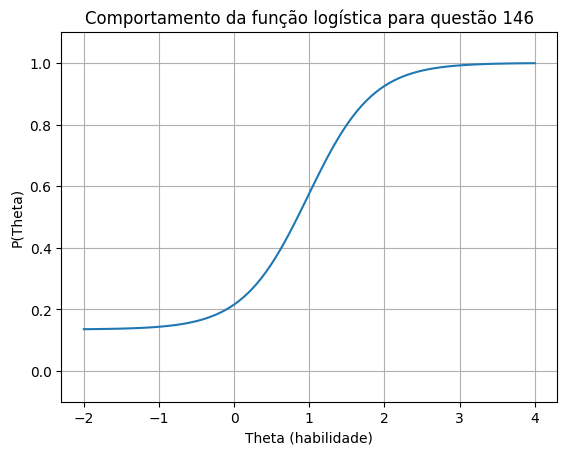

In [ ]:
q = 146
i = q - 141
if q > 166:
    i -=1
theta_range = np.linspace(-2, 4, 100)  # intervalo de valores de theta
P_values = P(theta_range, a_vec[i], b_vec[i], c_vec[i])  # calcule para os parâmetros da primeira questão

plt.ylim(-0.1,1.1)
plt.plot(theta_range, P_values)
plt.xlabel('Theta (habilidade)')
plt.ylabel('P(Theta)')
plt.title('Comportamento da função logística para questão '+str(q))
plt.grid(True)
plt.show()


In [ ]:
limites_theta = (df_train['NU_NOTA_MT'].min(), df_train['NU_NOTA_MT'].max())

# Função de erro para um candidato (vetores de a, b, c)
def erro_para_candidato(theta, respostas, a_vec, b_vec, c_vec):
    P_pred = P(theta, a_vec, b_vec, c_vec)
    return np.sum((respostas - P_pred) ** 2)

# Aproximação numérica da primeira derivada
def derivada_primeira(func, theta, respostas, a_vec, b_vec, c_vec, epsilon=1e-4):
    return (func(theta + epsilon, respostas, a_vec, b_vec, c_vec) - func(theta - epsilon, respostas, a_vec, b_vec, c_vec)) / (2 * epsilon)

# Aproximação numérica da segunda derivada
def derivada_segunda(func, theta, respostas, a_vec, b_vec, c_vec, epsilon=1e-4):
    return (derivada_primeira(func, theta + epsilon, respostas, a_vec, b_vec, c_vec, epsilon) -
            derivada_primeira(func, theta - epsilon, respostas, a_vec, b_vec, c_vec, epsilon)) / (2 * epsilon)

In [ ]:
def calcular_nota_estimativa(dados, questoes, a_vec, b_vec, c_vec, th=0.02):
    notas_TRI = []
    derivadas_segunda = []
    ranges_minimos = []
    dados = dados.copy()

    for _, linha in dados.iterrows():
        respostas = linha[questoes].values.astype(float)
        minimos_encontrados = []

        # Para capturar f(x) de cada mínimo
        valores_f = []

        def registrar_minimos(x, f, accept):
            if accept:
                minimos_encontrados.append(x[0])
                valores_f.append(f)

        resultado = basinhopping(
            erro_para_candidato,
            x0=[0],
            minimizer_kwargs={
                "method": "L-BFGS-B",
                "bounds": [limites_theta],
                "args": (respostas, a_vec, b_vec, c_vec),
                "options": {"ftol": 1e-2}
            },
            niter=25,
            disp=False,
            callback=registrar_minimos
        )

        theta = resultado.x[0]
        f_melhor = resultado.fun

        f_pior = max(erro_para_candidato(-10, respostas, a_vec, b_vec, c_vec), erro_para_candidato(10, respostas, a_vec, b_vec, c_vec))

        # Calcula segunda derivada no mínimo global
        segunda_derivada = derivada_segunda(erro_para_candidato, theta, respostas, a_vec, b_vec, c_vec, 5e-2)

        # Filtra mínimos locais com erro suficientemente próximo do melhor
        minimos_filtrados = [x for x, f in zip(minimos_encontrados, valores_f) if f <= f_melhor + (f_pior - f_melhor) * th]
        range_valores = [min(minimos_filtrados), max(minimos_filtrados)]

        # Armazena os resultados
        notas_TRI.append(theta)
        derivadas_segunda.append(segunda_derivada)
        ranges_minimos.append(range_valores)

    dados['NOTA_TRI_ESTIMADA'] = notas_TRI
    dados['DERIVADA_SEGUNDA'] = derivadas_segunda
    dados['ALCANCE_MINIMOS'] = ranges_minimos

    return dados


df_val = calcular_nota_estimativa(df_val, questoes, a_vec, b_vec, c_vec, 0.02)
df_val

,NU_NOTA_MT,Q141,Q142,Q143,Q144,Q145,Q146,Q147,Q148,Q149,...,Q179,Q180,Q181,Q182,Q183,Q184,Q185,NOTA_TRI_ESTIMADA,DERIVADA_SEGUNDA,ALCANCE_MINIMOS
183870,0.806711,0.0,1.0,0.0,1.0,1.0,0.0,0.0,0.0,0.0,...,1.0,1.0,1.0,0.0,0.0,1.0,1.0,0.744791,6.599211,"[0.7238456781340749, 0.7825103997573427]"
183871,-1.193422,0.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,1.0,1.0,0.0,-1.067839,1.985126,"[-1.6658192394392675, -0.9657502728587117]"
183873,-0.885648,0.0,0.0,0.0,1.0,1.0,0.0,0.0,0.0,0.0,...,1.0,0.0,0.0,0.0,0.0,0.0,0.0,-0.718789,2.642644,"[-0.8292306983716827, -0.6619974779302217]"
183874,0.788419,0.0,0.0,0.0,0.0,1.0,1.0,1.0,0.0,1.0,...,1.0,0.0,1.0,1.0,0.0,1.0,1.0,0.600892,3.372223,"[0.6006992823254211, 0.6058176411343122]"
183875,-0.268510,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,...,1.0,0.0,0.0,1.0,0.0,1.0,0.0,-0.201082,2.705072,"[-0.20327678770235247, -0.19431581160781677]"
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
187958,-1.103555,0.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0,0.0,...,0.0,0.0,1.0,0.0,0.0,0.0,0.0,-1.516499,0.588397,"[-1.6269793879344399, -1.4850667770326598]"
187959,-0.565150,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,...,1.0,0.0,0.0,0.0,0.0,0.0,1.0,-0.485606,3.396189,"[-0.48942489172495307, -0.4736123691718217]"
187960,1.676749,0.0,1.0,0.0,0.0,1.0,1.0,1.0,1.0,0.0,...,0.0,1.0,1.0,0.0,0.0,1.0,1.0,1.720447,11.026308,"[1.669582818626225, 1.7464549210678348]"
187961,-0.921436,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,1.0,0.0,-0.745493,2.611227,"[-0.7503360407955826, -0.7009579700791437]"


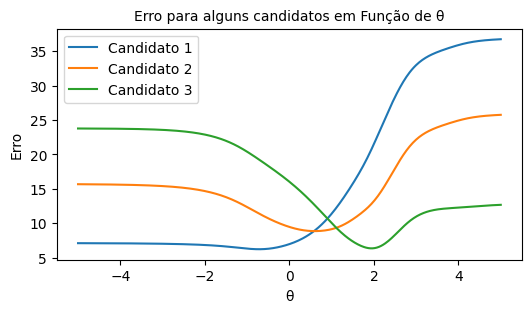

In [ ]:
candidatos = df_val.iloc[[2, 3, 6]]
erro_values_all = []

# Calcular os valores do erro para cada candidato no intervalo de -3 a 3
theta_values = np.linspace(-5, 5, 400)

for _, linha in candidatos.iterrows():
    respostas = linha[questoes].values.astype(float)
    erro_values = [erro_para_candidato(theta, respostas, a_vec, b_vec, c_vec) for theta in theta_values]
    erro_values_all.append(erro_values)

# Plotando o erro para todos os candidatos
plt.figure(figsize=(6, 3))

# Adiciona uma linha para cada candidato
for i, erro_values in enumerate(erro_values_all):
    plt.plot(theta_values, erro_values, label=f'Candidato {i+1}')

plt.title('Erro para alguns candidatos em Função de θ', fontsize=10)
plt.xlabel('θ')
plt.ylabel('Erro')
plt.legend()
plt.show()

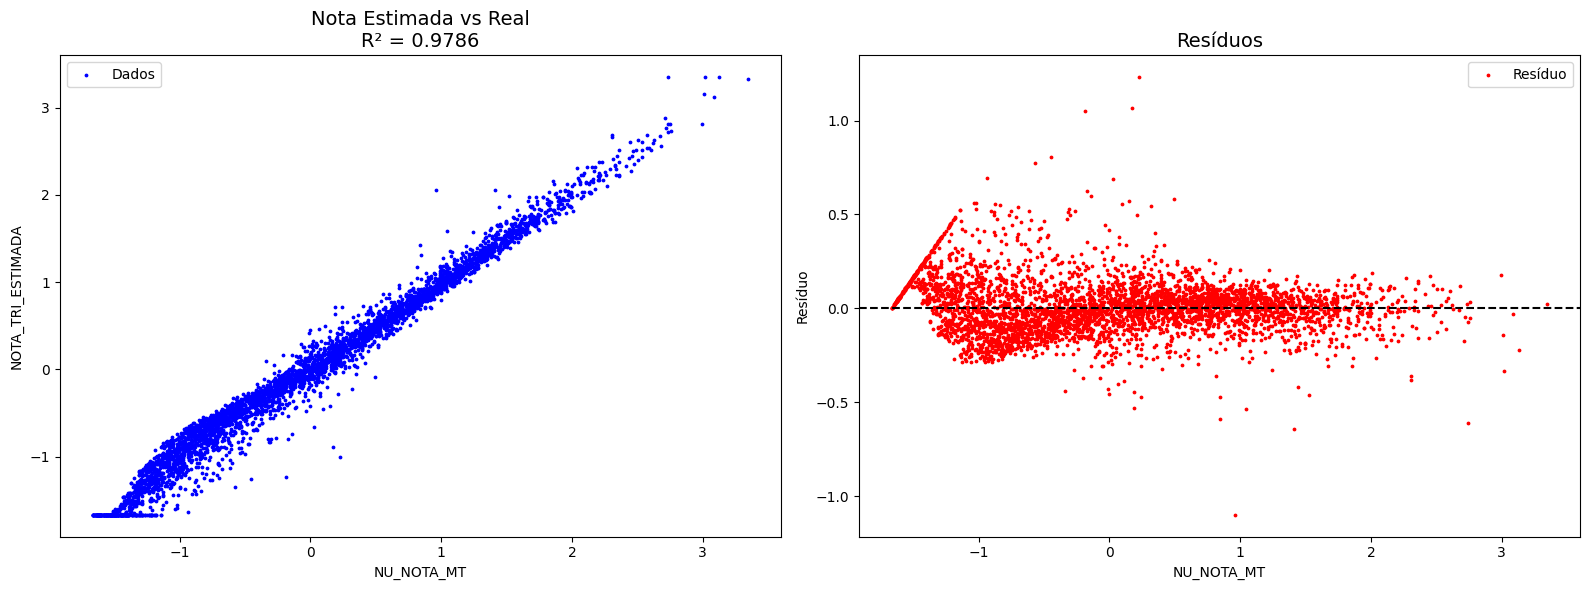

In [ ]:
r2 = r2_score(df_val['NU_NOTA_MT'], df_val['NOTA_TRI_ESTIMADA'])

# Criando os subplots
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Gráfico 1: Relação entre NU_NOTA_MT e NOTA_TRI_ESTIMADA
axes[0].scatter(df_val['NU_NOTA_MT'], df_val['NOTA_TRI_ESTIMADA'], s=3, color='blue', label='Dados')
axes[0].set_title(f'Nota Estimada vs Real\nR² = {r2:.4f}', fontsize=14)
axes[0].set_xlabel('NU_NOTA_MT')
axes[0].set_ylabel('NOTA_TRI_ESTIMADA')
axes[0].legend()

# Gráfico 2: Resíduo (diferença entre as duas colunas)
residuals = df_val['NU_NOTA_MT'] - df_val['NOTA_TRI_ESTIMADA']
axes[1].scatter(df_val['NU_NOTA_MT'], residuals, s=3, color='red', label='Resíduo')
axes[1].set_title('Resíduos', fontsize=14)
axes[1].set_xlabel('NU_NOTA_MT')
axes[1].set_ylabel('Resíduo')
axes[1].axhline(0, color='black', linestyle='--')  # Linha horizontal em zero
axes[1].legend()

# Exibindo os gráficos
plt.tight_layout()
plt.show()

In [ ]:
df_res = df_val[['NU_NOTA_MT', 'NOTA_TRI_ESTIMADA','DERIVADA_SEGUNDA','ALCANCE_MINIMOS']]
df_res['QTD_ACERTOS'] = df_val[[f'Q{i}' for i in range(141, 186) if i != 169]].sum(axis=1)
df_res['ALCANCE'] = df_res['ALCANCE_MINIMOS'].apply(lambda x: x[1] - x[0])
df_res

<ipython-input-19-60c4f463e8c6>:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_res['QTD_ACERTOS'] = df_val[[f'Q{i}' for i in range(141, 186) if i != 169]].sum(axis=1)
<ipython-input-19-60c4f463e8c6>:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_res['ALCANCE'] = df_res['ALCANCE_MINIMOS'].apply(lambda x: x[1] - x[0])


,NU_NOTA_MT,NOTA_TRI_ESTIMADA,DERIVADA_SEGUNDA,ALCANCE_MINIMOS,QTD_ACERTOS,ALCANCE
183870,0.806711,0.744791,6.599211,"[0.7238456781340749, 0.7825103997573427]",18.0,0.058665
183871,-1.193422,-1.067839,1.985126,"[-1.6658192394392675, -0.9657502728587117]",7.0,0.700069
183873,-0.885648,-0.718789,2.642644,"[-0.8292306983716827, -0.6619974779302217]",7.0,0.167233
183874,0.788419,0.600892,3.372223,"[0.6006992823254211, 0.6058176411343122]",18.0,0.005118
183875,-0.268510,-0.201082,2.705072,"[-0.20327678770235247, -0.19431581160781677]",11.0,0.008961
...,...,...,...,...,...,...
187958,-1.103555,-1.516499,0.588397,"[-1.6269793879344399, -1.4850667770326598]",7.0,0.141913
187959,-0.565150,-0.485606,3.396189,"[-0.48942489172495307, -0.4736123691718217]",9.0,0.015813
187960,1.676749,1.720447,11.026308,"[1.669582818626225, 1.7464549210678348]",27.0,0.076872
187961,-0.921436,-0.745493,2.611227,"[-0.7503360407955826, -0.7009579700791437]",7.0,0.049378


In [ ]:
df_res.columns

Index(['NU_NOTA_MT', 'NOTA_TRI_ESTIMADA', 'DERIVADA_SEGUNDA',
       'ALCANCE_MINIMOS', 'QTD_ACERTOS', 'ALCANCE'],
      dtype='object')

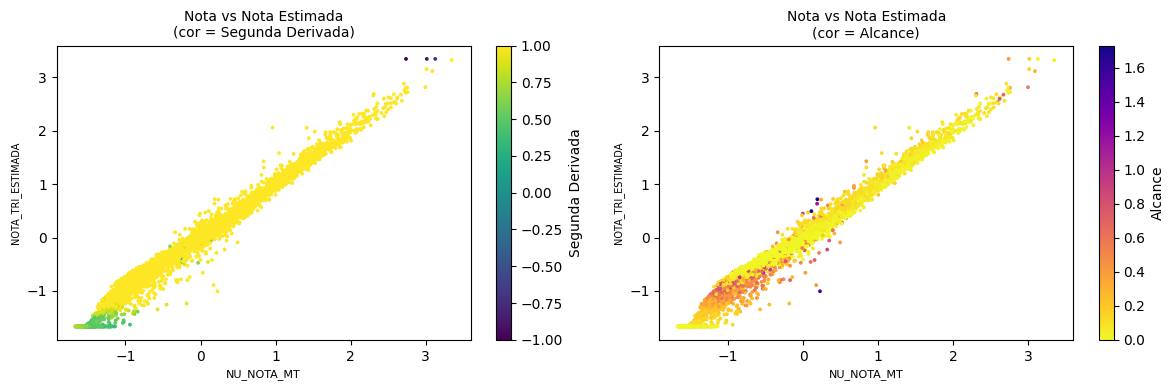

In [ ]:
# Criar figura com 2 subplots lado a lado
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Primeiro subplot: DERIVADA_SEGUNDA
sc1 = axes[0].scatter(df_res['NU_NOTA_MT'], df_res['NOTA_TRI_ESTIMADA'],
                      c=df_res['DERIVADA_SEGUNDA'], cmap='viridis', s=3,
                      vmin=-1, vmax=1)
axes[0].set_title('Nota vs Nota Estimada\n(cor = Segunda Derivada)', fontsize=10)
axes[0].set_xlabel('NU_NOTA_MT', fontsize=8)
axes[0].set_ylabel('NOTA_TRI_ESTIMADA', fontsize=7)
fig.colorbar(sc1, ax=axes[0], label='Segunda Derivada')

# Segundo subplot: ALCANCE com escala log e colormap invertido
sc2 = axes[1].scatter(df_res['NU_NOTA_MT'], df_res['NOTA_TRI_ESTIMADA'],
                      c=df_res['ALCANCE'], cmap='plasma_r', s=3)
axes[1].set_title('Nota vs Nota Estimada\n(cor = Alcance)', fontsize=10)
axes[1].set_xlabel('NU_NOTA_MT', fontsize=8)
axes[1].set_ylabel('NOTA_TRI_ESTIMADA', fontsize=7)
fig.colorbar(sc2, ax=axes[1], label='Alcance')

plt.tight_layout()
plt.show()


<ipython-input-22-5e3d3c36259b>:8: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_res['RESIDUO'] = df_res['NOTA_TRI_ESTIMADA'] - df_res['NU_NOTA_MT']


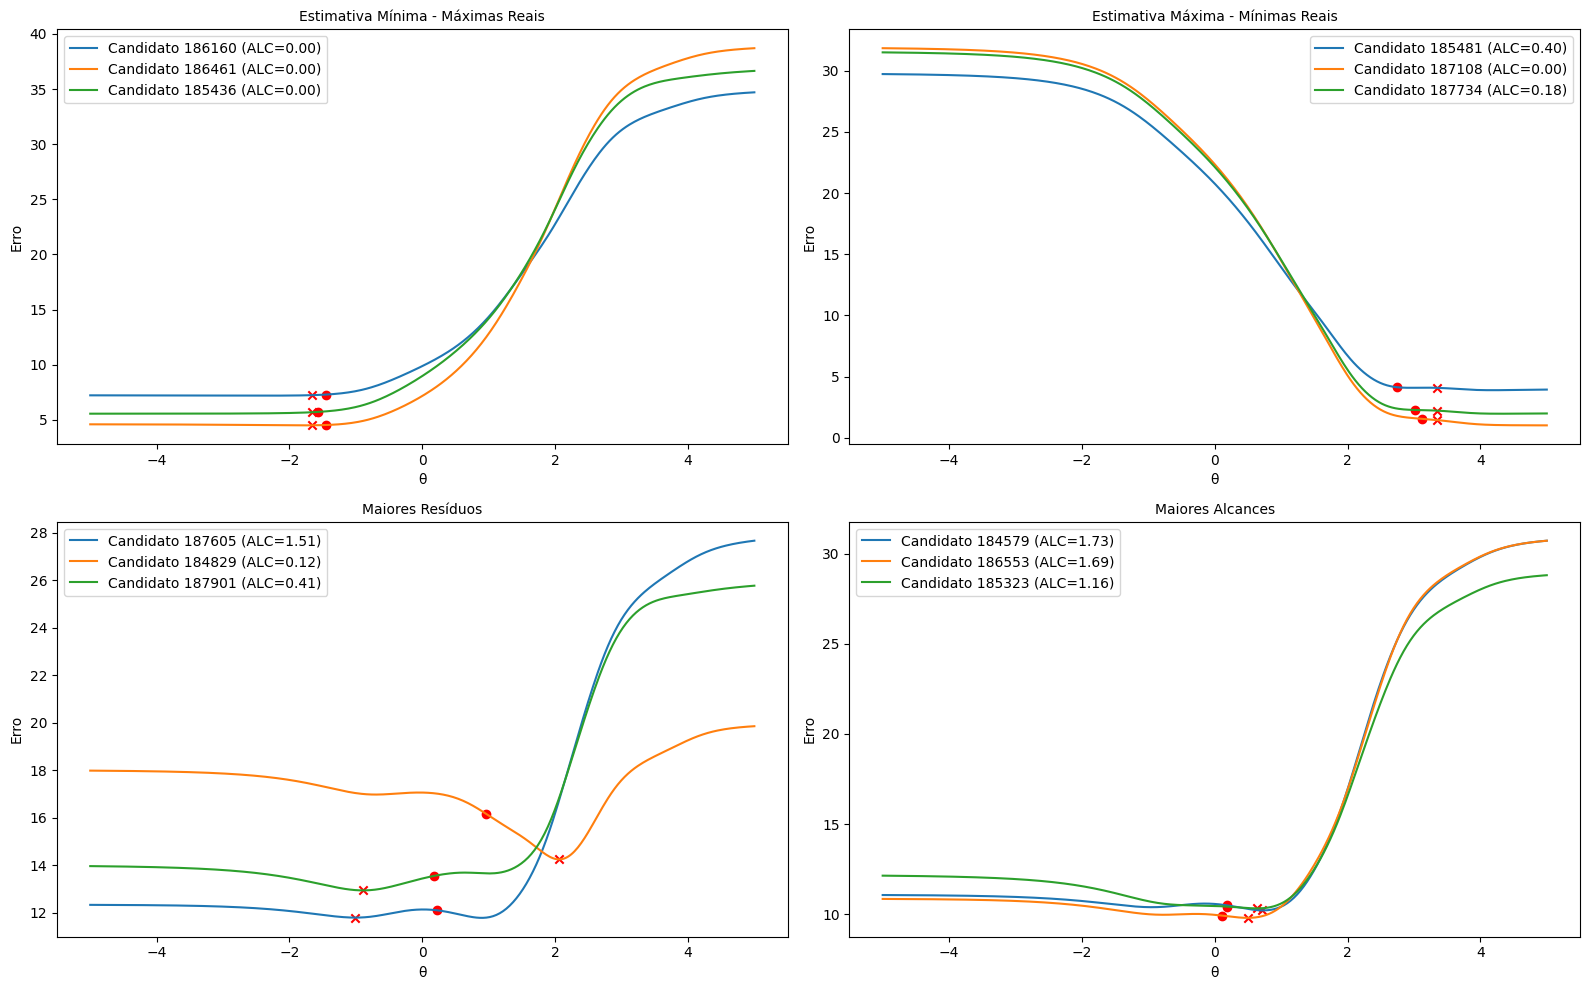

In [ ]:
# Passo 1: Filtrar questões com estimativa mínima
min_estimativa_questoes = df_res[df_res['NOTA_TRI_ESTIMADA'] == df_res['NOTA_TRI_ESTIMADA'].min()]

# Passo 2: Pegar as 3 máximas reais dentro das questões com estimativa mínima
top_min_estimativa = min_estimativa_questoes.sample(n=min(3, len(min_estimativa_questoes)), random_state=42)

# RESIDUO = estimada - real (diferença sem absoluto)
df_res['RESIDUO'] = df_res['NOTA_TRI_ESTIMADA'] - df_res['NU_NOTA_MT']

# Para escolher os top 3 maiores resíduos em valor absoluto, ignorando mínimo e máximo da estimada:
top_3_maiores_residuos = df_res[
    (df_res['NOTA_TRI_ESTIMADA'] != df_res['NOTA_TRI_ESTIMADA'].min()) &
    (df_res['NOTA_TRI_ESTIMADA'] != df_res['NOTA_TRI_ESTIMADA'].max())
].loc[lambda x: x['RESIDUO'].abs().nlargest(3).index]

# Passo 4: Pegar as questões com estimativa máxima
max_estimativa_questoes = df_res[df_res['NOTA_TRI_ESTIMADA'] == df_res['NOTA_TRI_ESTIMADA'].max()]

# Passo 5: Pegar as 3 mínimas reais dentro das questões com estimativa máxima
top_max_estimativa = max_estimativa_questoes.sample(n=min(3, len(max_estimativa_questoes)), random_state=42)

# Passo 6: Candidatos com maior alcance que ainda não foram mostrados
usados_idx = set(top_min_estimativa.index) | set(top_max_estimativa.index) | set(top_3_maiores_residuos.index)
top_alcance_novos = df_res[~df_res.index.isin(usados_idx)].nlargest(3, 'ALCANCE')

# Visualização com os 4 grupos
fig, axes = plt.subplots(2, 2, figsize=(16, 10))
axes = axes.flatten()
theta_values = np.linspace(-5, 5, 400)

# Função auxiliar para plotar
def plot_erro_subplot(indices, ax, titulo):
    for idx in indices:
        linha = df_val.loc[idx]
        respostas = linha[questoes].values.astype(float)
        erro_values = [erro_para_candidato(theta, respostas, a_vec, b_vec, c_vec) for theta in theta_values]

        ax.plot(theta_values, erro_values, label=f'Candidato {idx} (ALC={df_res.loc[idx, "ALCANCE"]:.2f})')
        ax.scatter(linha['NU_NOTA_MT'], erro_para_candidato(linha['NU_NOTA_MT'], respostas, a_vec, b_vec, c_vec),
                   color='red', marker='o')
        ax.scatter(linha['NOTA_TRI_ESTIMADA'], erro_para_candidato(linha['NOTA_TRI_ESTIMADA'], respostas, a_vec, b_vec, c_vec),
                   color='red', marker='x')

    ax.set_title(titulo, fontsize=10)
    ax.set_xlabel('θ')
    ax.set_ylabel('Erro')
    ax.legend()

# Plotando cada subplot
plot_erro_subplot(top_min_estimativa.index, axes[0], 'Estimativa Mínima - Máximas Reais')
plot_erro_subplot(top_max_estimativa.index, axes[1], 'Estimativa Máxima - Mínimas Reais')
plot_erro_subplot(top_3_maiores_residuos.index, axes[2], 'Maiores Resíduos')
plot_erro_subplot(top_alcance_novos.index, axes[3], 'Maiores Alcances')

plt.tight_layout()
plt.show()


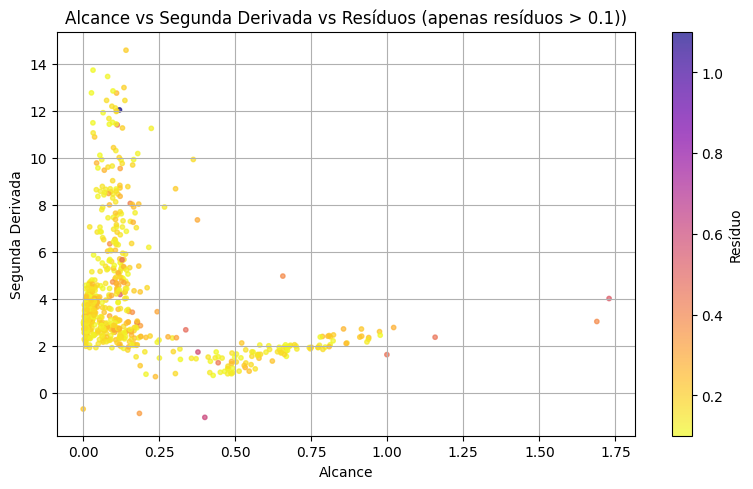

In [ ]:
fth = 0.10
df_filtrado = df_res[df_res['RESIDUO'] > fth].copy()

plt.figure(figsize=(8, 5))
sc = plt.scatter(
    df_filtrado['ALCANCE'],
    df_filtrado['DERIVADA_SEGUNDA'],
    c=df_filtrado['RESIDUO'],
    cmap='plasma_r',
    alpha=0.7,
    s=10)

plt.xlabel('Alcance')
plt.ylabel('Segunda Derivada')
plt.title(f'Alcance vs Segunda Derivada vs Resíduos (apenas resíduos > {fth}))')
plt.colorbar(sc, label='Resíduo')
plt.grid(True)
plt.tight_layout()
plt.show()


<ipython-input-24-c0af6ed5657a>:16: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_res['RESIDUO_ABS'] = df_res['RESIDUO'].abs()


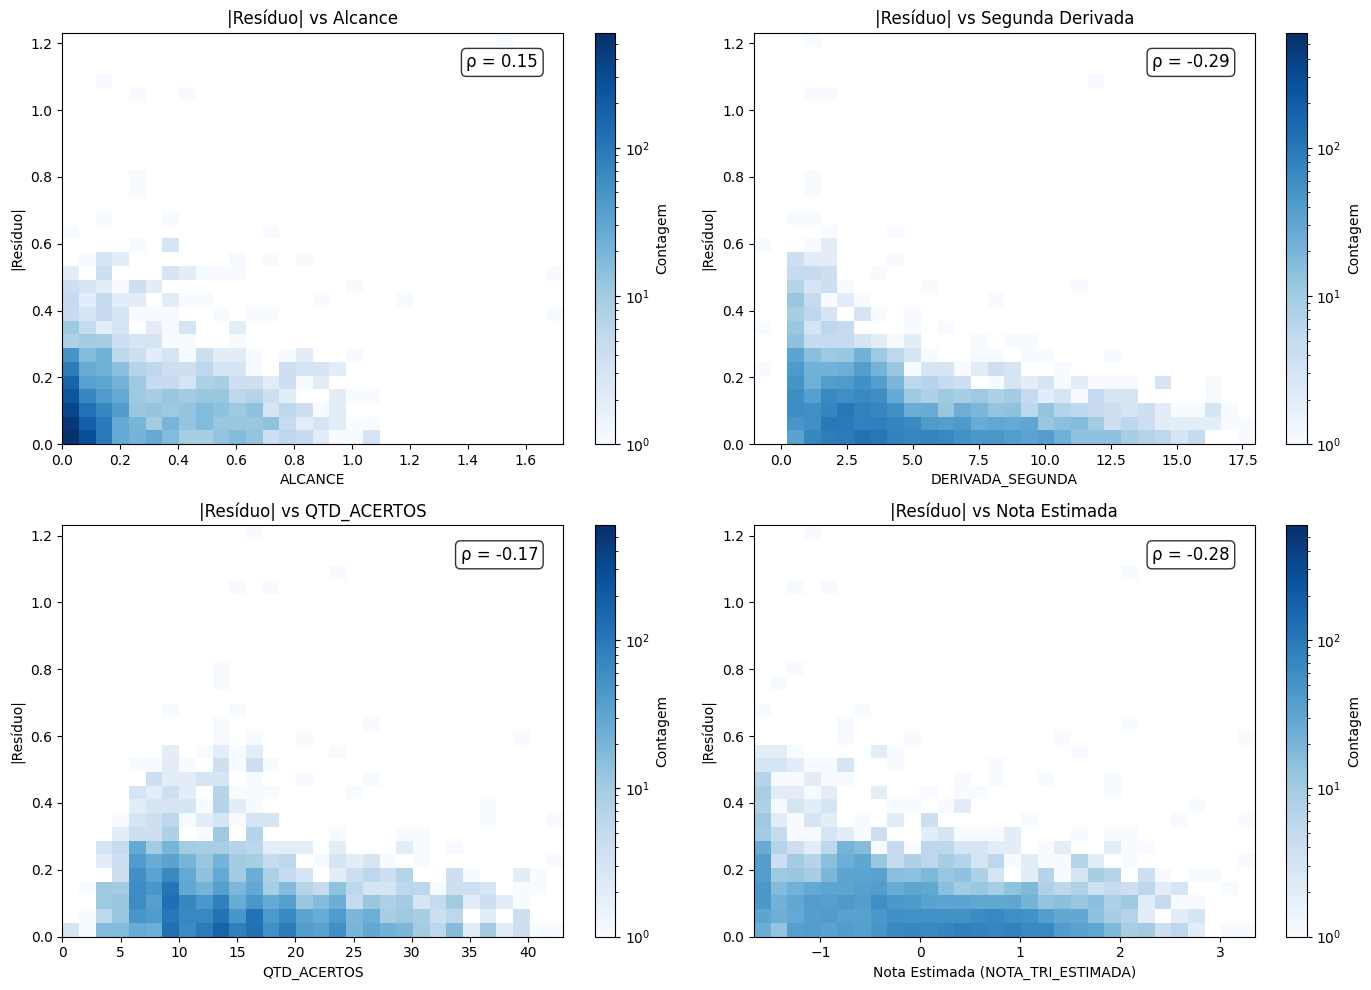

In [ ]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

bins_x = 30
bins_y = 30
cmap = 'Blues'

# Agora substituí 'NU_NOTA_MT' por 'NOTA_TRI_ESTIMADA' na lista de plots
plots = [
    ('ALCANCE', 'RESIDUO', 'Resíduo vs Alcance'),
    ('DERIVADA_SEGUNDA', 'RESIDUO', 'Resíduo vs Segunda Derivada'),
    ('QTD_ACERTOS', 'RESIDUO', 'Resíduo vs QTD_ACERTOS'),
    ('NOTA_TRI_ESTIMADA', 'RESIDUO', 'Resíduo vs Nota Estimada'),  # Aqui a mudança
]

# Criar uma nova coluna para o resíduo absoluto
df_res['RESIDUO_ABS'] = df_res['RESIDUO'].abs()

y_col_abs = 'RESIDUO_ABS'

counts_max = 0
hist_data = []
for x_col, _, _ in plots:
    counts, xedges, yedges = np.histogram2d(
        df_res[x_col], df_res[y_col_abs],
        bins=[bins_x, bins_y],
        range=[[df_res[x_col].min(), df_res[x_col].max()], [0, df_res[y_col_abs].max()]]
    )
    hist_data.append((counts, xedges, yedges))
    counts_max = max(counts_max, counts.max())

norm = colors.LogNorm(vmin=1, vmax=counts_max)

for ax, (counts, xedges, yedges), (x_col, _, title) in zip(axes.flatten(), hist_data, plots):
    mesh = ax.pcolormesh(
        xedges, yedges, counts.T, cmap=cmap, norm=norm, shading='auto'
    )
    ax.set_xlabel(x_col if x_col != 'NOTA_TRI_ESTIMADA' else 'Nota Estimada (NOTA_TRI_ESTIMADA)')
    ax.set_ylabel('|Resíduo|')
    ax.set_title(title.replace('Resíduo', '|Resíduo|'))
    ax.set_ylim(0, df_res[y_col_abs].max())
    cbar = fig.colorbar(mesh, ax=ax)
    cbar.set_label('Contagem')

    x_data = df_res[x_col]
    y_data = df_res[y_col_abs]
    corr_coef, p_value = pearsonr(x_data, y_data)

    ax.text(
        0.95, 0.95,
        f'ρ = {corr_coef:.2f}',
        transform=ax.transAxes,
        ha='right',
        va='top',
        fontsize=12,
        bbox=dict(boxstyle='round,pad=0.3', facecolor='white', alpha=0.8)
    )

plt.tight_layout()
plt.show()


###Segundo treinamento

In [ ]:
X = df_res[['ALCANCE', 'DERIVADA_SEGUNDA', 'QTD_ACERTOS', 'NOTA_TRI_ESTIMADA']]
y = df_res['NU_NOTA_MT']

model = xgb.XGBRegressor(objective='reg:squarederror', random_state=0)

kf = KFold(n_splits=5, shuffle=True, random_state=42)

# Obtem predições via validação cruzada
y_pred = cross_val_predict(model, X, y, cv=kf)

rmse = mean_squared_error(y, y_pred)**0.5
r2 = r2_score(y, y_pred)

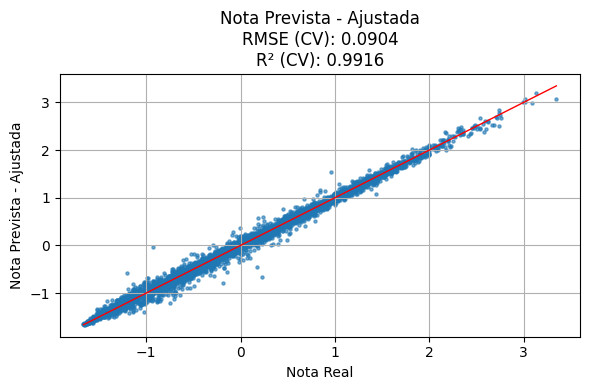

In [ ]:
plt.figure(figsize=(6, 4))
plt.scatter(y, y_pred, alpha=0.6, s=5)
plt.plot([y.min(), y.max()], [y.min(), y.max()], 'r-', lw=1)
plt.xlabel('Nota Real')
plt.ylabel('Nota Prevista - Ajustada')
plt.title(f'Nota Prevista - Ajustada vs Nota Real\nRMSE (CV): {rmse:.4f}\nR² (CV): {r2:.4f}')
plt.grid(True)
plt.tight_layout()
plt.show()

###Avaliação final

In [ ]:
df_test = calcular_nota_estimativa(df_test, questoes, a_vec, b_vec, c_vec, 0.02)
df_test['QTD_ACERTOS'] = df_test[[f'Q{i}' for i in range(141, 186) if i != 169]].sum(axis=1)
df_test = df_test[['NU_NOTA_MT', 'NOTA_TRI_ESTIMADA','DERIVADA_SEGUNDA','ALCANCE_MINIMOS','QTD_ACERTOS']]
df_test['ALCANCE'] = df_test['ALCANCE_MINIMOS'].apply(lambda x: x[1] - x[0])
df_test

,NU_NOTA_MT,NOTA_TRI_ESTIMADA,DERIVADA_SEGUNDA,ALCANCE_MINIMOS,QTD_ACERTOS,ALCANCE
187963,1.400786,1.584025,6.351457,"[1.5187524977325355, 1.588516408619467]",25.0,0.069764
187964,-0.600142,-0.463649,3.316094,"[-0.4643589749389412, -0.45652529318985924]",8.0,0.007834
187965,-1.366793,-1.491875,0.729010,"[-1.6201765724583619, -1.4841356644741084]",6.0,0.136041
187966,-0.021972,-0.026321,2.521326,"[-0.03177588085238295, -0.023993089662478075]",13.0,0.007783
187967,-0.008453,-0.244537,2.461562,"[-0.24942161886833034, -0.23603699506658637]",15.0,0.013385
...,...,...,...,...,...,...
192066,0.455196,0.394700,5.337144,"[0.3827698615859973, 0.4190438800724465]",17.0,0.036274
192067,0.611072,0.545448,4.259603,"[0.5301593984814266, 0.597471482089035]",16.0,0.067312
192068,-0.849065,-0.795365,1.839395,"[-1.1031367453675525, -0.635293383530855]",10.0,0.467843
192069,-0.634339,-0.379273,1.833657,"[-0.5504767013641529, -0.26977701688144745]",8.0,0.280700


In [ ]:
# Definindo as features e target do treino
X_val = df_res[['ALCANCE', 'DERIVADA_SEGUNDA', 'QTD_ACERTOS', 'NOTA_TRI_ESTIMADA']]
y_val = df_res['NU_NOTA_MT']

# Features do teste
X_test = df_test[['ALCANCE', 'DERIVADA_SEGUNDA', 'QTD_ACERTOS', 'NOTA_TRI_ESTIMADA']]

In [ ]:
# 1. Criar e treinar o modelo com todos os dados de treino
model = xgb.XGBRegressor(objective='reg:squarederror', random_state=0)
model.fit(X_val, y_val)

# 2. Fazer predição no conjunto de teste
y_test_pred = model.predict(X_test)

# 3. Avaliar modelo obtido
y_test = df_test['NU_NOTA_MT']
rmse_test = mean_squared_error(y_test, y_test_pred)**0.5
r2_test = r2_score(y_test, y_test_pred)

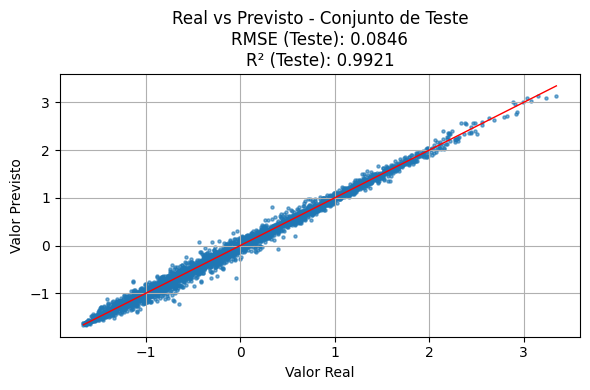

In [ ]:
# Plotar real x previsto
plt.figure(figsize=(6, 4))
plt.scatter(y_test, y_test_pred, alpha=0.6, s=5)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r-', lw=1)
plt.xlabel('Valor Real')
plt.ylabel('Valor Previsto')
plt.title(f'Real vs Previsto - Conjunto de Teste\nRMSE (Teste): {rmse_test:.4f}\nR² (Teste): {r2_test:.4f}')
plt.grid(True)
plt.tight_layout()
plt.show()
